In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import files
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


```python
ax.text(dt, year_y, str(dt.year),
          ha="center", va=year_va, fontsize=16, fontweight='bold', color='black') # Increased fontsize for year
```

In [23]:
# Upload Excel file
uploaded = files.upload()
file_path = list(uploaded.keys())[0]
data = pd.ExcelFile(file_path)

Saving Arthospira.xlsx to Arthospira (1).xlsx


In [24]:
df = data.parse('Sheet1')
df['Date'] = pd.to_datetime(df['Date'].astype(str), format='%Y')
timeline_df = pd.DataFrame(data={"Year":df['Date'], "Events":df['Event'], "level":df['Level']})
# The line below is no longer needed as 'level' is now taken directly from df['Level']
# default_levels = [7, -7] * (len(timeline_df) // 2 + 1)
# default_levels = default_levels[:len(timeline_df)]
# timeline_df['level'] = default_levels

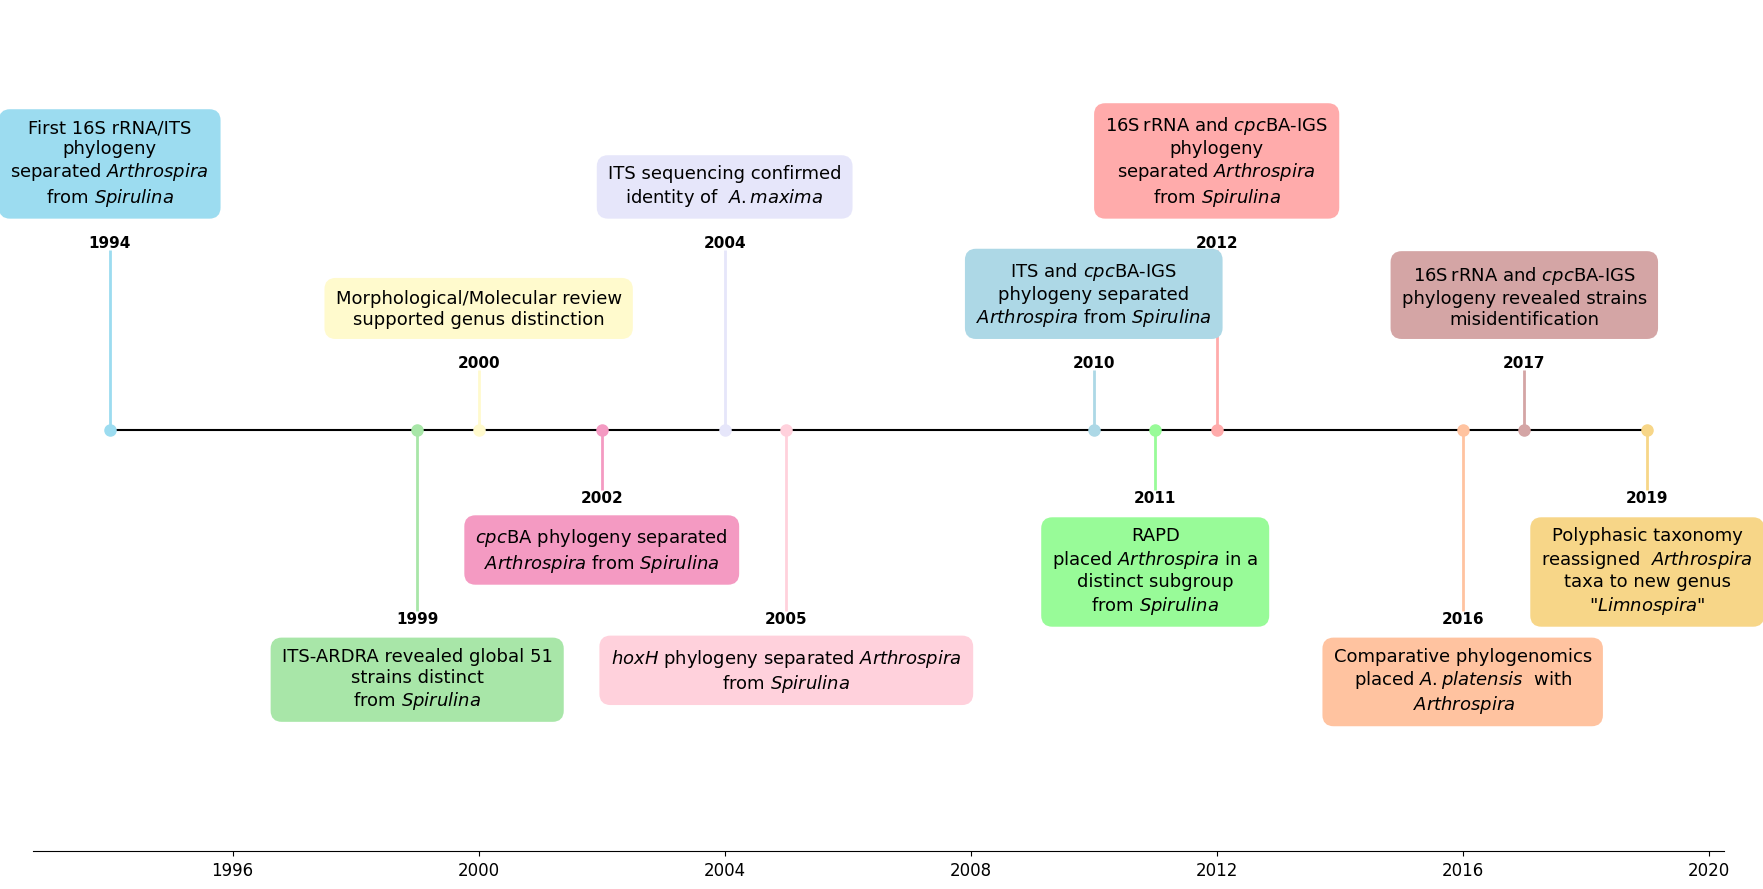

In [30]:
import textwrap
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Define an extended list of pastel colors to avoid repetition for the current number of events
pastel_colors = [
    '#e3f6fc', '#A8E6A8', '#FFFACD', '#F49AC2', '#E6E6FA', # Original 5 (changed #77DD77 to #A8E6A8 for lighter green, #b59eaf to #E6E6FA for lavender)
    '#FFD1DC', '#ADD8E6', '#98FB98', '#FFABAB', '#FFC3A0', # Pink, Light Blue, Pale Green, Light Red, Peach
    '#D4A5A5', '#C4B7AC', '#B5D8CC', '#98DED9', '#8A9A5B', # Rosy Brown, Silver Sand, Mint, Turquoise, Olive Green
    '#87CEEB', '#88B04B', '#9ACD32', '#FFFDD0', '#EEDC82', # Sky Blue, Dark Olive Green, Yellow Green, Cream, Khaki
    '#FFDEAD', '#DEB887', '#FFEBCD', '#E9C46A', '#FFB7B2'  # Navajo White, Burly Wood, Blanched Almond, Mustard, Light Coral
]

fig, ax = plt.subplots(figsize=(18,9))
ax.plot(df.Date, [0,]* len(timeline_df), "-", color="black") # Removed markers from this line
ax.set_ylim(-7,7)
ax.spines[["left","top","right"]].set_visible(False)
ax.yaxis.set_visible(False)

# Increase the font size for the x-axis tick labels (years)
ax.tick_params(axis='x', labelsize=12)
# Make x-axis tick labels bold
# for label in ax.get_xticklabels():
#     label.set_fontweight('bold')

# Define separate widths for top and bottom text wrapping
top_text_width = 31
bottom_text_width = 25 # You can adjust this value for desired wrapping below the timeline

# Define a specific width for the year 2012
width_2012 = 10 # Adjust this value for desired wrapping in 2012

# Loop to draw events (stems, markers, and annotations)
for idx in range(len(timeline_df)):
  dt = timeline_df["Year"].iloc[idx]
  event_text = timeline_df['Events'].iloc[idx]
  text_level = timeline_df["level"].iloc[idx] # This is where the text and arrow end

  # Get a pastel color based on the index
  if dt.year == 1994:
      current_pastel_color = '#9cdcf0'
  elif dt.year == 2019:
      current_pastel_color = '#f7d688'
  else:
      current_pastel_color = pastel_colors[idx % len(pastel_colors)]

  # Draw the dot on the timeline with the current pastel color
  ax.plot(dt, 0, "o", color=current_pastel_color, markerfacecolor=current_pastel_color, markersize=8, zorder=3)

  # Wrap the original event text first based on text_level and year
  if dt.year == 2012:
      wrapped_text = textwrap.fill(event_text, width=30)
  elif dt.year == 2005:
      wrapped_text = textwrap.fill(event_text, width=40) # Custom width for year 2005
  elif dt.year == 2017:
      wrapped_text = textwrap.fill(event_text, width=30)
  elif dt.year == 2010:
      wrapped_text = textwrap.fill(event_text, width=26)
  elif dt.year == 1994:
      wrapped_text = textwrap.fill(event_text, width=25)
  elif dt.year == 2002:
      wrapped_text = textwrap.fill(event_text, width=28)
  elif dt.year == 1999:
      wrapped_text = textwrap.fill(event_text, width=30)
  elif text_level > 0:
      wrapped_text = textwrap.fill(event_text, width=top_text_width)
  else:
      wrapped_text = textwrap.fill(event_text, width=bottom_text_width)

  # Now, replace specific words with MathText for italics using raw strings
  # This is applied to the already wrapped text
  wrapped_text = wrapped_text.replace("Arthrospira", r"$\it{Arthrospira}$")
  wrapped_text = wrapped_text.replace("Limnospira", r"$\it{Limnospira}$")
  wrapped_text = wrapped_text.replace("Spirulina", r"$\it{Spirulina}$")
  wrapped_text = wrapped_text.replace("Planktothrix", r"$\it{Planktothrix}$")
  wrapped_text = wrapped_text.replace("hoxH", r"$\it{hoxH}$")
  wrapped_text = wrapped_text.replace("cpc", r"$\it{cpc}$")
  wrapped_text = wrapped_text.replace("A.platensis", r"$\it{A.platensis}$")
  wrapped_text = wrapped_text.replace("A.fusiformis", r"$\it{A.fusiformis}$")
  wrapped_text = wrapped_text.replace("A.maxima", r"$\it{A.maxima}$") # Added A.maxima
  wrapped_text = wrapped_text.replace("Oscillatoria", r"$\it{Oscillatoria}$")
  wrapped_text = wrapped_text.replace("Lyngbya", r"$\it{Lyngbya}$")
  wrapped_text = wrapped_text.replace("Microcoleus", r"$\it{Microcoleus}$")

  # Draw the stem (vertical line) using the current pastel color
  ax.vlines(dt, 0, text_level, color=current_pastel_color, lw=2)

  # Determine vertical alignment and y-coordinates for separate text elements
  if text_level > 0:
      # Text is above the timeline
      year_y = text_level # Year is at the tip
      year_va = "bottom"  # Year's bottom edge is at text_level
      text_y = text_level + 0.7 # Text above the year, increased spacing for bbox
      text_va = "bottom"     # Text's bottom edge is at text_y
  else:
      # Text is below the timeline
      year_y = text_level # Year is at the tip
      year_va = "top"     # Year's top edge is at text_level
      text_y = text_level - 0.6 # Text below the year, increased spacing for bbox
      text_va = "top"  # Text's top edge is at text_y

  # bbox_props with current_pastel_color for face color and edge, and increased linewidth
  bbox_props = dict(boxstyle="round,pad=0.5", fc=current_pastel_color, ec=current_pastel_color, lw=3.0) # Increased lw to make outline bolder

  # Draw the bold year
  ax.text(dt, year_y, str(dt.year),
          ha="center", va=year_va, fontsize=11, fontweight='bold', color='black') # Changed fontsize to 11 for year labels

  # Draw the wrapped event text (non-bold, with MathText italics)
  ax.text(dt, text_y, wrapped_text,
          ha="center", # <--- Adjust horizontal alignment here ('left', 'center', 'right')
          va=text_va,  # <--- Adjust vertical alignment here ('top', 'bottom', 'center')
          fontsize=13, # <--- Adjust font size here
          color='black', bbox=bbox_props)

plt.tight_layout()
# Save the plot as a PNG file before showing it
plt.savefig('timeline_plot.png')
plt.show()

```python
ax.text(dt, year_y, str(dt.year),
          ha="center", va=year_va, fontsize=20, fontweight='bold', color='black') # Increased fontsize for year
```

In [31]:
from google.colab import files
files.download('timeline_plot.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>